# Naik — Income-Shock Pricing Kernel (Tweedie GLM)

**Block 3 deliverable.** This notebook derives the pricing kernel behind Naik's
parametric income-protection micro-cover. The cover pays a Shopee gig worker a
multiple of her daily earnings when a BMKG weather index crosses a threshold at
her kecamatan; this model estimates the **expected weekly income loss** that the
premium must cover.

**Model.** A Tweedie GLM with `var_power = 1.5` and a log link. Tweedie (a
compound Poisson–Gamma) is the right tool because the loss has a point mass at
zero (no flood → no income shock) plus a positive continuous tail (flood →
lost earnings). `p = 1.5` sits between Poisson (`p=1`) and Gamma (`p=2`); the
log link gives interpretable multiplicative rating relativities.

**Methodology ported from prior actuarial work** (motor-portfolio Tweedie
pricing): the Lorenz/Gini discrimination metric (`gini = 1 − 2·area`, ordering
by predicted pure premium), the log-link Tweedie specification, and the
decile-lift / calibration diagnostics.

**Modelling note — `flood_event_occurred` is deliberately excluded from the
predictors.** At quote time the flood has not happened; it is the insured
event. Using it as a feature is target leakage. It drives the data-generating
process (creating the Tweedie zero-mass + severity shape) and the model prices
off the *ex-ante* features `income_decile`, `flood_risk_score`, `gig_worker`,
`household_size`. Section 5 demonstrates the leakage explicitly.

In [2]:
import json
import subprocess
import sys
import textwrap
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels.api as sm
from sklearn.linear_model import TweedieRegressor
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (7, 4)

SEED = 2025
VAR_POWER = 1.5            # Tweedie power p (compound Poisson–Gamma)
N = 5000                   # synthetic policy-years
FEATURES = ["income_decile", "flood_risk_score", "gig_worker", "household_size"]
TARGET = "weekly_income_loss_idr"
np.random.seed(SEED)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk up until we find the repo root (contains both `agents` and `api`)."""
    here = (start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "agents").is_dir() and (cand / "api").is_dir():
            return cand
    return here  # fall back to CWD


REPO_ROOT = find_repo_root()
MODEL_PATH = REPO_ROOT / "agents" / "pricing" / "income_shock_glm.joblib"
print("repo root :", REPO_ROOT)
print("model out :", MODEL_PATH)
print("sklearn   :", sklearn.__version__)

repo root : C:\Users\Omistaja\Downloads\files (49)
model out : C:\Users\Omistaja\Downloads\files (49)\agents\pricing\income_shock_glm.joblib
sklearn   : 1.3.0


## Gini (ported from prior work)

Order observations by **predicted** pure premium (ascending), trace the
cumulative share of **actual** losses against the cumulative share of
exposure (the Lorenz curve), and take `gini = 1 − 2 × (area under the curve)`.
Higher Gini ⇒ the model concentrates predicted losses on the genuinely
high-loss policies, i.e. better risk discrimination.

In [3]:
def lorenz_gini(actual, predicted) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    order = np.argsort(predicted, kind="mergesort")        # stable: deterministic ties
    a = actual[order]
    n = len(a)
    cum_actual = np.cumsum(a) / a.sum()
    cum_pop = np.arange(1, n + 1) / n
    cp = np.concatenate(([0.0], cum_pop))
    ca = np.concatenate(([0.0], cum_actual))
    area = np.sum(np.diff(cp) * (ca[:-1] + ca[1:]) / 2.0)  # trapezoidal
    return 1.0 - 2.0 * area

## 1 · Synthetic data generation (5,000 policy-years)

- `income_decile` ∈ 1..10 → maps to a Jakarta-like monthly income curve.
- `flood_risk_score` ∈ (0,1) assigned **by kecamatan** (25 districts, each with
  its own Beta-drawn risk), so policies cluster by district risk.
- `gig_worker` (Bernoulli) — gig/informal income has no paid leave, so a flood
  bites harder.
- `household_size` — mild severity amplifier.
- `flood_event_occurred` (Bernoulli, probability rising in `flood_risk_score`)
  — the realised insured event that switches the loss on.

**Target** `weekly_income_loss_idr`: zero if no flood; otherwise
`weekly_income × lost_weeks`, with `lost_weeks` Gamma-distributed and amplified
by gig status, district risk, and household size — the compound Poisson–Gamma
shape Tweedie is built for.

In [4]:
def make_data(n=N, seed=SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    K = 25
    district_risk = rng.beta(2.0, 3.0, size=K)
    kec = rng.integers(0, K, size=n)
    flood_risk_score = district_risk[kec]

    income_decile = rng.integers(1, 11, size=n)
    gig_worker = (rng.random(n) < 0.55).astype(int)
    household_size = np.clip(1 + rng.poisson(1.8, size=n), 1, 8)

    p_event = np.clip(0.08 + 0.55 * flood_risk_score, 0.02, 0.85)
    flood_event_occurred = (rng.random(n) < p_event).astype(int)

    monthly_income = 2_200_000 * (1.20 ** (income_decile - 1))
    weekly_income = monthly_income / 4.33

    gig_factor = np.where(gig_worker == 1, 1.5, 1.0)
    risk_factor = 1.0 + 0.8 * flood_risk_score
    hh_factor = 1.0 + 0.04 * (household_size - 1)
    mean_lost_weeks = 1.0 * gig_factor * risk_factor * hh_factor
    shape = 2.0
    lost_weeks = np.minimum(rng.gamma(shape, mean_lost_weeks / shape, size=n), 8.0)

    loss = np.where(flood_event_occurred == 1, weekly_income * lost_weeks, 0.0)

    return pd.DataFrame({
        "income_decile": income_decile.astype(int),
        "flood_risk_score": flood_risk_score.astype(float),
        "gig_worker": gig_worker.astype(int),
        "household_size": household_size.astype(int),
        "flood_event_occurred": flood_event_occurred.astype(int),
        "monthly_income_idr": np.round(monthly_income).astype(int),
        TARGET: np.round(loss).astype(float),
    })


df = make_data()
print(f"rows                : {len(df):,}")
print(f"zero-loss share     : {np.mean(df[TARGET] == 0):.1%}")
print(f"flood event freq    : {df['flood_event_occurred'].mean():.1%}")
print(f"mean loss (all)     : Rp {df[TARGET].mean():,.0f}")
print(f"mean loss | flood   : Rp {df.loc[df.flood_event_occurred == 1, TARGET].mean():,.0f}")
df.head()

rows                : 5,000
zero-loss share     : 69.5%
flood event freq    : 30.5%
mean loss (all)     : Rp 734,496
mean loss | flood   : Rp 2,406,605


,income_decile,flood_risk_score,gig_worker,household_size,flood_event_occurred,monthly_income_idr,weekly_income_loss_idr
0,9,0.536815,0,3,0,9459597,0.0
1,1,0.269387,1,3,0,2200000,0.0
2,2,0.053610,1,3,0,2640000,0.0
3,8,0.549581,0,1,1,7882998,2565769.0
4,4,0.337184,0,1,1,3801600,881255.0


In [4]:
df.describe().round(2)

,income_decile,flood_risk_score,gig_worker,household_size,flood_event_occurred,monthly_income_idr,weekly_income_loss_idr
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,5.53,0.40,0.56,2.76,0.31,5730145.86,734495.97
std,2.86,0.20,0.50,1.33,0.46,2899899.00,1725246.48
min,1.00,0.05,0.00,1.00,0.00,2200000.00,0.00
25%,3.00,0.27,0.00,2.00,0.00,3168000.00,0.00
50%,6.00,0.35,1.00,3.00,0.00,5474304.00,0.00
75%,8.00,0.55,1.00,4.00,1.00,7882998.00,613262.25
max,10.00,0.76,1.00,8.00,1.00,11351517.00,20972779.00


## 2 · Exploratory view — the Tweedie shape

A spike at zero (most policy-years see no flood) and a right-skewed positive
tail among flood years. Loss frequency rises with district flood risk.

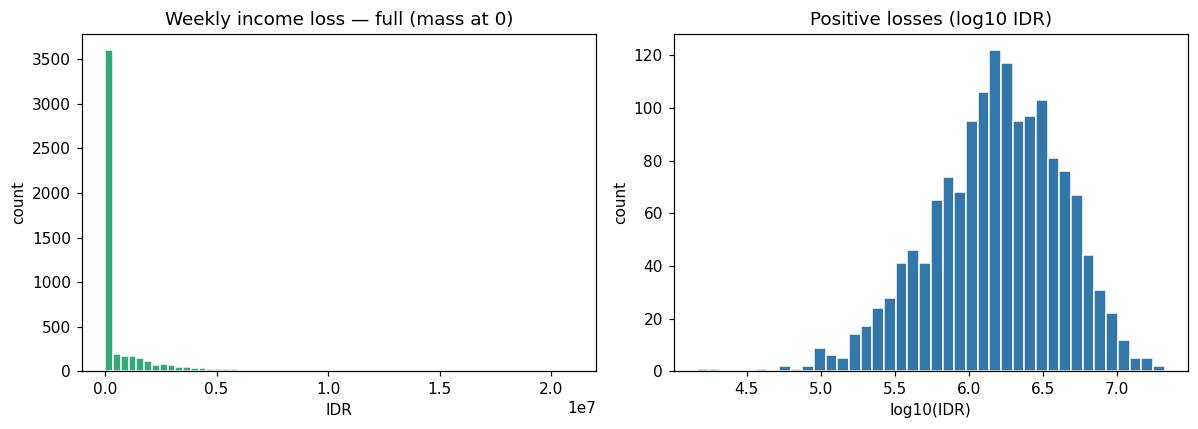

Event frequency by flood-risk band:
flood_risk_score
(0.0, 0.2]    13.9 %
(0.2, 0.4]    24.2 %
(0.4, 0.6]    38.1 %
(0.6, 0.8]    44.7 %
Name: flood_event_occurred, dtype: object


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df[TARGET], bins=60, color="#3a7", edgecolor="white")
ax[0].set_title("Weekly income loss — full (mass at 0)")
ax[0].set_xlabel("IDR"); ax[0].set_ylabel("count")

pos = df.loc[df[TARGET] > 0, TARGET]
ax[1].hist(np.log10(pos), bins=40, color="#37a", edgecolor="white")
ax[1].set_title("Positive losses (log10 IDR)")
ax[1].set_xlabel("log10(IDR)"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

# frequency by flood-risk band
band = pd.cut(df["flood_risk_score"], bins=[0, .2, .4, .6, .8, 1.0])
freq = df.groupby(band, observed=True)["flood_event_occurred"].mean()
print("Event frequency by flood-risk band:")
print((freq * 100).round(1).astype(str) + " %")

## 3 · Fit the Tweedie GLM (`var_power = 1.5`, log link)

80/20 train/holdout split. The deployed model is fit on the **ex-ante**
features only.

In [6]:
X = df[FEATURES]
y = df[TARGET].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=SEED)
print(f"train: {len(y_tr):,}   holdout: {len(y_te):,}")

model = TweedieRegressor(power=VAR_POWER, link="log", alpha=1e-6,
                         max_iter=100_000, tol=1e-8)
model.fit(X_tr, y_tr)

relativities = pd.DataFrame({
    "coef": model.coef_,
    "exp(coef)": np.exp(model.coef_),
}, index=FEATURES)
print(f"intercept = {model.intercept_:.4f}  (base exp = Rp {np.exp(model.intercept_):,.0f})\n")
print("Rating relativities (multiplicative effect per unit increase):")
relativities.round(4)

train: 4,000   holdout: 1,000
intercept = 10.8761  (base exp = Rp 52,897)

Rating relativities (multiplicative effect per unit increase):


,coef,exp(coef)
income_decile,0.1643,1.1786
flood_risk_score,2.5720,13.0924
gig_worker,0.4363,1.5470
household_size,0.0613,1.0632


### Cross-check against statsmodels + actuarial diagnostics

Re-fit the identical specification in statsmodels for a full GLM summary
(coefficients, standard errors, deviance, dispersion φ). The two libraries
should agree to numerical precision — a guard against a silent solver issue.

In [7]:
X_tr_c = sm.add_constant(X_tr.astype(float))
sm_res = sm.GLM(
    y_tr, X_tr_c,
    family=sm.families.Tweedie(link=sm.families.links.Log(), var_power=VAR_POWER),
).fit()

sk_pred_te = model.predict(X_te)
sm_pred_te = sm_res.predict(sm.add_constant(X_te.astype(float)))
corr = np.corrcoef(sk_pred_te, sm_pred_te)[0, 1]
phi = sm_res.scale  # Pearson dispersion estimate

print(sm_res.summary())
print(f"\nsklearn vs statsmodels holdout-prediction correlation : {corr:.6f}")
print(f"residual deviance : {sm_res.deviance:,.0f}")
print(f"dispersion  φ     : {phi:,.1f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4000
Model:                            GLM   Df Residuals:                     3995
Model Family:                 Tweedie   Df Model:                            4
Link Function:                    Log   Scale:                          3342.5
Method:                          IRLS   Log-Likelihood:                -21275.
Date:                Tue, 02 Jun 2026   Deviance:                   1.2012e+07
Time:                        07:51:51   Pearson chi2:                 1.34e+07
No. Iterations:                    12   Pseudo R-squ. (CS):             0.1084
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               10.8761      0.136  

## 4 · Performance — Gini on the 20% holdout (primary deliverable)

Target: **Gini > 0.10**. We also check train-set balance (a log-link MLE GLM is
self-balancing on the training data), the decile lift table, and the Lorenz
curve.

In [8]:
pred_te = model.predict(X_te)
pred_tr = model.predict(X_tr)

gini_holdout = lorenz_gini(y_te, pred_te)
gini_train = lorenz_gini(y_tr, pred_tr)

print(f"HOLDOUT Gini : {gini_holdout:.4f}   (train {gini_train:.4f})")
print(f"target > 0.10 -> {'PASS' if gini_holdout > 0.10 else 'FAIL'}")
assert gini_holdout > 0.10, "Holdout Gini below target 0.10"

print(f"\ntrain-set balance  (Σpred/Σactual) : {pred_tr.sum() / y_tr.sum():.4f}")
print(f"holdout calibration (Σpred/Σactual): {pred_te.sum() / y_te.sum():.4f}")

HOLDOUT Gini : 0.4617   (train 0.3706)
target > 0.10 -> PASS

train-set balance  (Σpred/Σactual) : 1.0030
holdout calibration (Σpred/Σactual): 0.8496


In [9]:
# Decile lift table on the holdout (deciles by predicted pure premium)
lift = pd.DataFrame({"actual": y_te, "pred": pred_te})
lift["decile"] = pd.qcut(lift["pred"].rank(method="first"), 10, labels=False) + 1
lift_tbl = lift.groupby("decile").agg(
    n=("actual", "size"),
    mean_actual=("actual", "mean"),
    mean_pred=("pred", "mean"),
)
print("Decile lift (holdout) — mean actual vs predicted, Rp:")
lift_tbl.round(0)

Decile lift (holdout) — mean actual vs predicted, Rp:


,n,mean_actual,mean_pred
decile,,,
1,100,153208.0,152115.0
2,100,270219.0,243987.0
3,100,342778.0,319705.0
4,100,294501.0,406235.0
5,100,381209.0,505141.0
6,100,646417.0,607442.0
7,100,974208.0,752407.0
8,100,927065.0,946265.0
9,100,1791702.0,1213087.0


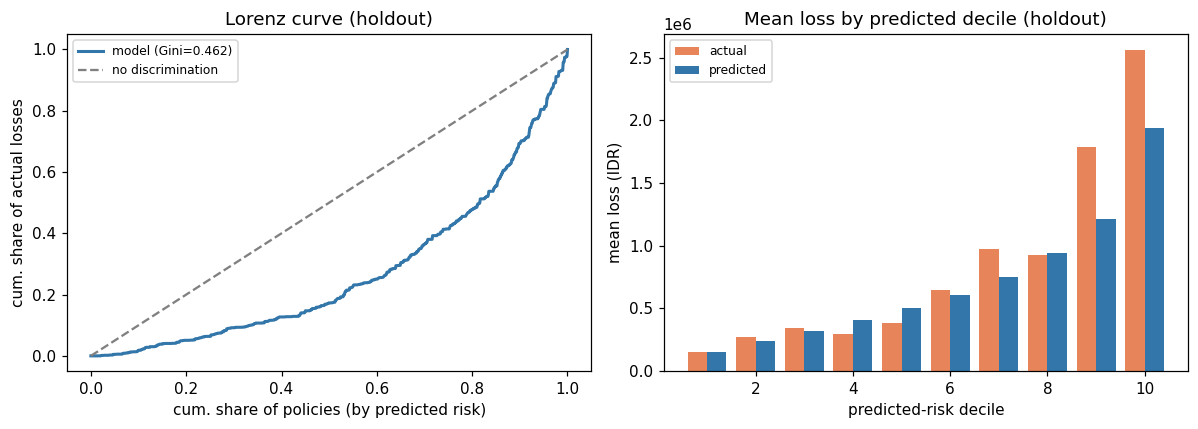

In [10]:
# Lorenz curve + decile lift bar
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

order = np.argsort(pred_te)
cum_pop = np.concatenate(([0], np.arange(1, len(y_te) + 1) / len(y_te)))
cum_loss = np.concatenate(([0], np.cumsum(y_te[order]) / y_te.sum()))
ax[0].plot(cum_pop, cum_loss, color="#37a", lw=2, label=f"model (Gini={gini_holdout:.3f})")
ax[0].plot([0, 1], [0, 1], "--", color="grey", label="no discrimination")
ax[0].set_title("Lorenz curve (holdout)")
ax[0].set_xlabel("cum. share of policies (by predicted risk)")
ax[0].set_ylabel("cum. share of actual losses")
ax[0].legend(loc="upper left", fontsize=8)

w = 0.4
idx = lift_tbl.index.to_numpy()
ax[1].bar(idx - w / 2, lift_tbl["mean_actual"], w, label="actual", color="#e8845a")
ax[1].bar(idx + w / 2, lift_tbl["mean_pred"], w, label="predicted", color="#37a")
ax[1].set_title("Mean loss by predicted decile (holdout)")
ax[1].set_xlabel("predicted-risk decile"); ax[1].set_ylabel("mean loss (IDR)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Gini stability — repeated holdout

A single split can flatter or punish a model. Re-fit on 50 independent 80/20
splits to confirm the discrimination is robust, not a lucky partition.

repeated-holdout Gini  mean=0.3863  sd=0.0291  min=0.3190  p05=0.3376
all 50 folds > 0.10 -> True


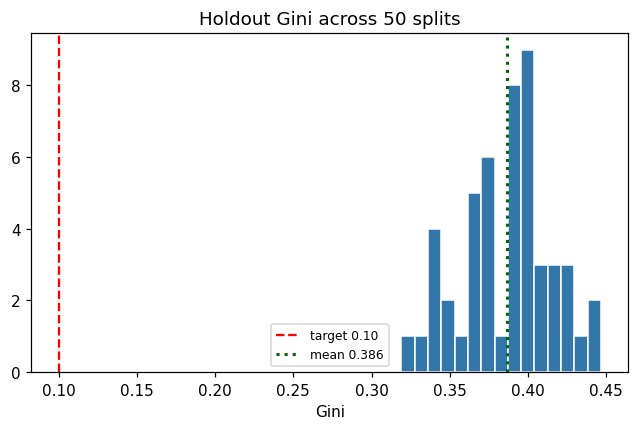

In [11]:
ginis = []
for s in range(50):
    a, b, c, d = train_test_split(X, y, test_size=0.20, random_state=1000 + s)
    m = TweedieRegressor(power=VAR_POWER, link="log", alpha=1e-6, max_iter=50_000)
    m.fit(a, c)
    ginis.append(lorenz_gini(d, m.predict(b)))
ginis = np.array(ginis)

print(f"repeated-holdout Gini  mean={ginis.mean():.4f}  sd={ginis.std():.4f}  "
      f"min={ginis.min():.4f}  p05={np.percentile(ginis, 5):.4f}")
print(f"all 50 folds > 0.10 -> {(ginis > 0.10).all()}")

plt.figure()
plt.hist(ginis, bins=15, color="#37a", edgecolor="white")
plt.axvline(0.10, color="red", ls="--", lw=1.5, label="target 0.10")
plt.axvline(ginis.mean(), color="darkgreen", ls=":", lw=2, label=f"mean {ginis.mean():.3f}")
plt.title("Holdout Gini across 50 splits"); plt.xlabel("Gini"); plt.legend(fontsize=8)
plt.show()

## 5 · Leakage demonstration — why `flood_event_occurred` is excluded

Adding the realised flood event as a predictor inflates the Gini sharply,
because the event almost determines the loss. But that information does not
exist at quote time, so a model that relies on it cannot price a forward-looking
policy. We show the inflated number, then discard this model.

In [12]:
leak_feats = FEATURES + ["flood_event_occurred"]
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(df[leak_feats], y, test_size=0.20,
                                              random_state=SEED)
leak = TweedieRegressor(power=VAR_POWER, link="log", alpha=1e-6, max_iter=100_000)
leak.fit(Xl_tr, yl_tr)
gini_leak = lorenz_gini(yl_te, leak.predict(Xl_te))
print(f"Gini WITH flood_event_occurred (leaky)   : {gini_leak:.4f}")
print(f"Gini WITHOUT (deployed, ex-ante features): {gini_holdout:.4f}")
print("→ The leaky model is discarded; the deployed kernel prices off ex-ante risk only.")

Gini WITH flood_event_occurred (leaky)   : 0.7975
Gini WITHOUT (deployed, ex-ante features): 0.4617
→ The leaky model is discarded; the deployed kernel prices off ex-ante risk only.


## 6 · Serialise the pricing kernel

We persist a self-describing bundle (no custom classes), so a fresh process
needs only `scikit-learn` + `joblib` to load and predict. The insurance agent
(Block 4) reads `feature_names` to build the input frame and calls
`model.predict`.

In [13]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
bundle = {
    "model": model,
    "feature_names": FEATURES,
    "target": TARGET,
    "var_power": VAR_POWER,
    "link": "log",
    "gini_holdout": float(gini_holdout),
    "gini_holdout_repeated_mean": float(ginis.mean()),
    "dispersion_phi": float(phi),
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "sklearn_version": sklearn.__version__,
    "schema_version": "1.0.0",
    "n_train": int(len(y_tr)),
    "seed": SEED,
}
joblib.dump(bundle, MODEL_PATH)
print(f"serialised -> {MODEL_PATH}")
print(f"size       : {MODEL_PATH.stat().st_size:,} bytes")
print("metadata   :")
print(json.dumps({k: v for k, v in bundle.items() if k != "model"}, indent=2))

serialised -> /home/claude/naik/agents/pricing/income_shock_glm.joblib
size       : 1,668 bytes
metadata   :
{
  "feature_names": [
    "income_decile",
    "flood_risk_score",
    "gig_worker",
    "household_size"
  ],
  "target": "weekly_income_loss_idr",
  "var_power": 1.5,
  "link": "log",
  "gini_holdout": 0.46167421353870086,
  "gini_holdout_repeated_mean": 0.3863072862231222,
  "dispersion_phi": 3342.4951562428737,
  "trained_at": "2026-06-02T07:51:52.988504+00:00",
  "sklearn_version": "1.5.2",
  "schema_version": "1.0.0",
  "n_train": 4000,
  "seed": 2025
}


In [14]:
# In-notebook reload sanity check
reloaded = joblib.load(MODEL_PATH)
sample = pd.DataFrame([{
    "income_decile": 3, "flood_risk_score": 0.6, "gig_worker": 1, "household_size": 4,
}])[reloaded["feature_names"]]
print(f"reloaded Gini metadata : {reloaded['gini_holdout']:.4f}")
print(f"sample prediction      : Rp {reloaded['model'].predict(sample)[0]:,.0f} expected weekly loss")

reloaded Gini metadata : 0.4617
sample prediction      : Rp 801,236 expected weekly loss


## 7 · Confirm load in a *fresh* Python process

The notebook kernel already imported everything; the real test is a brand-new
interpreter that imports nothing first. We shell out to a clean `python -c`,
load the artifact, and predict.

In [15]:
code = textwrap.dedent(f"""
    import joblib, pandas as pd
    b = joblib.load(r"{MODEL_PATH}")
    row = pd.DataFrame([{{"income_decile":3,"flood_risk_score":0.6,
                          "gig_worker":1,"household_size":4}}])[b["feature_names"]]
    print("OK gini=%.4f pred=%d" % (b["gini_holdout"], round(float(b["model"].predict(row)[0]))))
""")
res = subprocess.run([sys.executable, "-c", code], capture_output=True, text=True)
print("fresh-process stdout:", res.stdout.strip())
if res.returncode != 0:
    print("stderr:", res.stderr.strip())
assert res.returncode == 0 and "OK" in res.stdout, "Fresh-process load failed"
print("✓ loads and predicts in a fresh process")

fresh-process stdout: OK gini=0.4617 pred=801236
✓ loads and predicts in a fresh process


## 8 · Hand-off to the insurance agent (Block 4)

The kernel returns **expected weekly income loss** `E[L]` for a user's risk
profile. The insurance agent turns that into the `InsuranceQuote` fields:

- `expected_annual_loss_idr` ≈ `E[L]` scaled to the coverage term.
- `payout_per_event_idr` = `estimated_daily_earnings_idr × payout_multiple`
  (sized from Shopee transaction velocity, not from this model).
- `premium_idr` = `expected_loss × (1 + risk/expense/profit loadings)`, then the
  schema guardrail enforces `premium_idr < payout_per_event_idr`.

This separation keeps the statistical kernel (what we expect to pay) distinct
from the commercial premium (what we charge), which the compliance agent reviews.